<a href="https://colab.research.google.com/github/Sharpice078/ResNetTrial/blob/main/ResNetTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch;
print(torch.__version__);
print(torch.cuda.is_available())

2.11.0+cu130
True


100%|██████████| 170M/170M [20:46<00:00, 137kB/s]


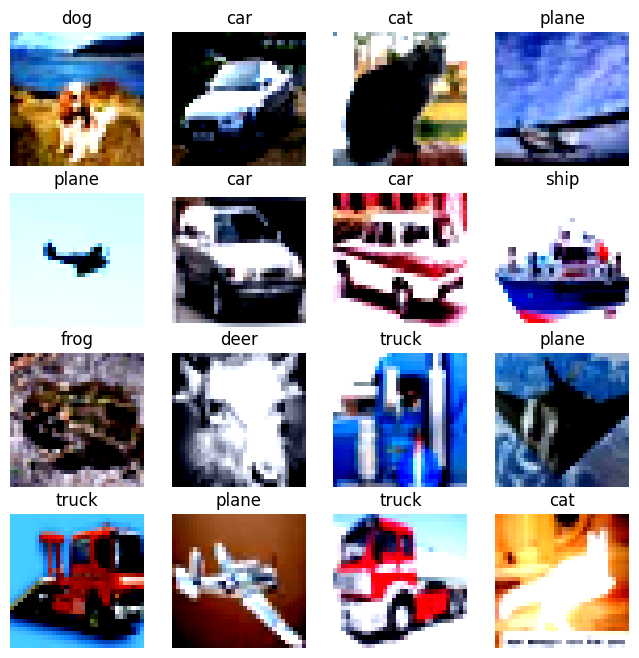

训练集大小：50000；单张图片形状：torch.Size([3, 32, 32])


In [2]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 数据预处理：先只转 tensor，暂时不做复杂增强
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=16, shuffle=True, num_workers=2
)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# 取一个 batch 并可视化
images, labels = next(iter(trainloader))
plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i+1)
    img = images[i] / 2 + 0.5  # 反归一化，方便显示
    plt.imshow(img.permute(1, 2, 0).numpy())
    plt.title(classes[labels[i]])
    plt.axis('off')
plt.show()

print(f"训练集大小：{len(trainset)}；单张图片形状：{images[0].shape}")
